<a href="https://colab.research.google.com/github/manubastidas/programacionCientifica/blob/eval2-GuarinOrtiz/Evaluacion2/GuarinOrtiz/solucion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importación de librerías

In [1]:
# Librerías para manejo de arreglos y operaciones numéricas
import numpy as np

# Librería para realizar las gráficas
import matplotlib.pyplot as plt

# JAX y su versión de NumPy
import jax
import jax.numpy as jnp

# Funciones necesarias para inicialización, gradientes y compilación
from jax import random, grad, jit

# Cargar datos

In [2]:
# Cargar el archivo .npz que contiene las señales
datos = np.load("../SolucionReferencia_0000/datos_0000.npz", allow_pickle=True)

# Matriz de señales (45 señales de longitud 256)
X = datos["X"]

# Etiqueta del régimen de cada señal
y = datos["y"]

# Vector de tiempo asociado a las muestras
t = datos["t"]

# Mostrar dimensiones para verificar que la carga fue correcta
print(X.shape)
print(y.shape)

(24, 256)
(24,)


# Graficar una señal de cada régimen

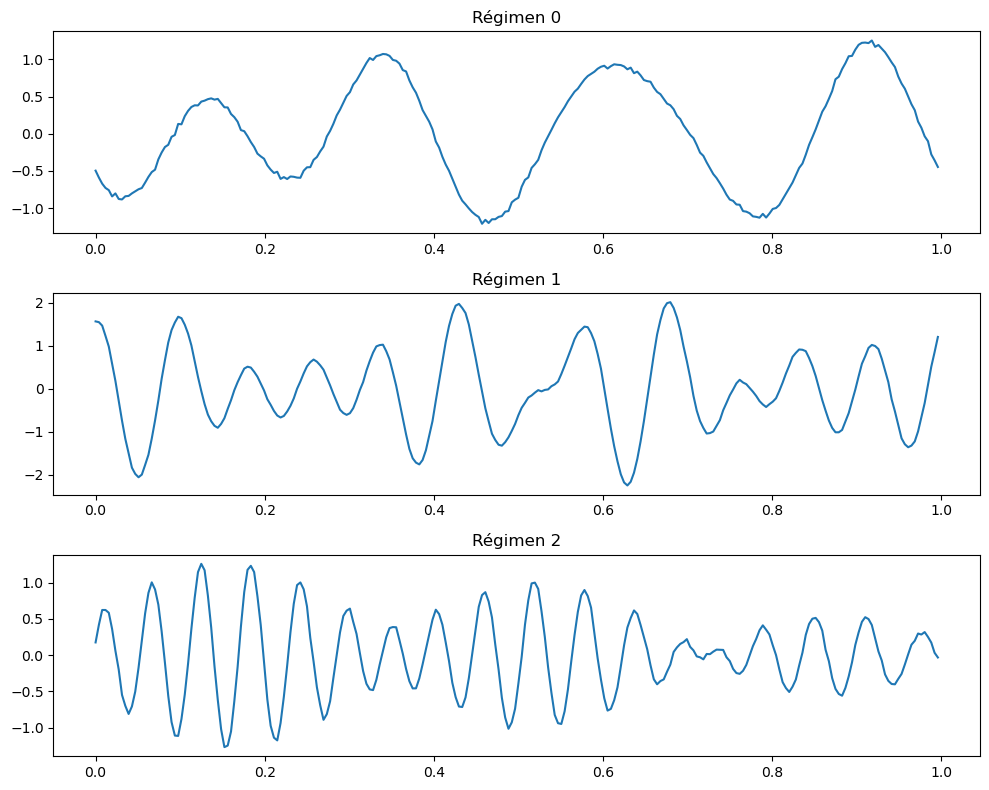

In [3]:
# Crear una figura con tres subgráficas
fig, ax = plt.subplots(3, 1, figsize=(10,8))

# Recorrer los tres regímenes disponibles
for r in range(3):

    # Buscar el índice de la primera señal perteneciente al régimen r
    indice = np.where(y == r)[0][0]

    # Graficar la señal correspondiente
    ax[r].plot(t, X[indice])

    # Agregar un título descriptivo
    ax[r].set_title(f"Régimen {r}")

# Ajustar automáticamente el espacio entre gráficas
plt.tight_layout()

# Construcción de la matriz de Fourier

In [4]:
# Número de frecuencias que utilizará la capa
K = 25

# Cantidad de muestras por señal
N = len(t)

# La matriz tendrá 2K filas:
# una fila seno y una fila coseno para cada frecuencia
W_fourier = np.zeros((2*K, N))

# Construir la base frecuencia por frecuencia
for k in range(1, K+1):

    # Fila correspondiente al coseno de frecuencia k
    W_fourier[2*(k-1)] = np.cos(2*np.pi*k*t)

    # Fila correspondiente al seno de frecuencia k
    W_fourier[2*(k-1)+1] = np.sin(2*np.pi*k*t)

# Calcular los coeficientes

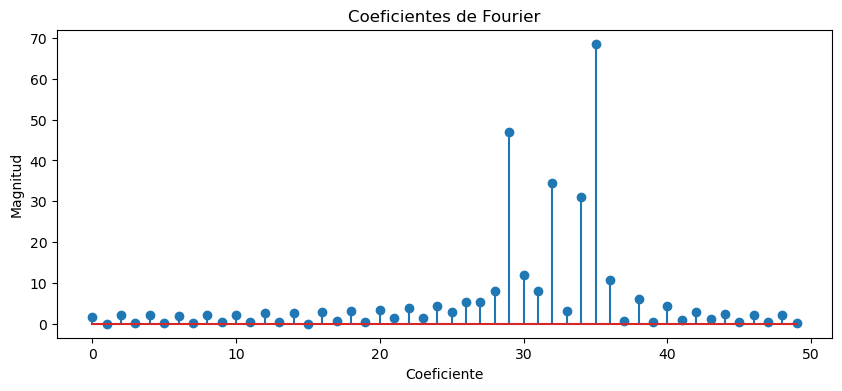

In [5]:
# Seleccionar una señal para el ejemplo
x = X[0]

# Proyectar la señal sobre la base de Fourier
coef = W_fourier @ x

# Graficar la magnitud de los coeficientes obtenidos
plt.figure(figsize=(10,4))
plt.stem(np.abs(coef))

plt.title("Coeficientes de Fourier")
plt.xlabel("Coeficiente")
plt.ylabel("Magnitud")

plt.show()

# Inicialización aleatoria

In [6]:
def init_random(key):

    # Dividir la llave para inicializar ambas capas
    k1, k2 = random.split(key)

    # Primera capa con pesos aleatorios pequeños
    W1 = random.normal(k1, (2*K,256)) * 0.1

    # Segunda capa con pesos aleatorios pequeños
    W2 = random.normal(k2, (256,2*K)) * 0.1

    return W1, W2

# Inicialización Fourier

In [7]:
def init_fourier(key):

    # Solo necesitamos una llave para inicializar la segunda capa
    _, k2 = random.split(key)

    # La primera capa comienza exactamente con la base de Fourier
    W1 = jnp.array(W_fourier)

    # La segunda capa sigue siendo aleatoria
    W2 = random.normal(k2, (256,2*K)) * 0.1

    return W1, W2

# Forward

In [8]:
def forward(params, x):

    # Desempaquetar los pesos de ambas capas
    W1, W2 = params

    # Aplicar la primera transformación lineal y la activación tanh
    h = jnp.tanh(W1 @ x)

    # Reconstrucción de la señal mediante la segunda capa
    return W2 @ h

# Función de pérdida

In [9]:
def loss(params, X):

    # Reconstruir todas las señales usando vectorización
    pred = jax.vmap(lambda z: forward(params, z))(X)

    # Calcular el error cuadrático medio
    return jnp.mean((pred - X)**2)

# Descenso por gradiente

In [10]:
@jit
def step(params, X, lr):

    # Calcular el gradiente de la pérdida respecto a los pesos
    grads = grad(loss)(params, X)

    new = []

    # Actualizar cada conjunto de pesos mediante descenso por gradiente
    for p, g in zip(params, grads):

        new.append(p - lr*g)

    return tuple(new)

# Entrenamiento

In [11]:
def train(params, X, epochs=3000, lr=0.05):

    # Lista donde se almacenará la evolución de la pérdida
    history = []

    # Repetir el proceso de entrenamiento
    for i in range(epochs):

        # Actualizar los parámetros
        params = step(params, X, lr)

        # Guardar la pérdida cada 10 iteraciones
        if i % 10 == 0:

            history.append(loss(params, X))

    return params, np.array(history)

# Entrenar ambas redes

In [12]:
# Crear una llave para generar los pesos aleatorios
key = random.PRNGKey(0)

# Inicializar la red con pesos completamente aleatorios
params_random = init_random(key)

# Inicializar la red usando la base de Fourier en la primera capa
params_fourier = init_fourier(key)

# Entrenar la red con inicialización aleatoria
params_random, h_random = train(params_random, jnp.array(X))

# Entrenar la red con inicialización Fourier
params_fourier, h_fourier = train(params_fourier, jnp.array(X))

# Comparación de la pérdida

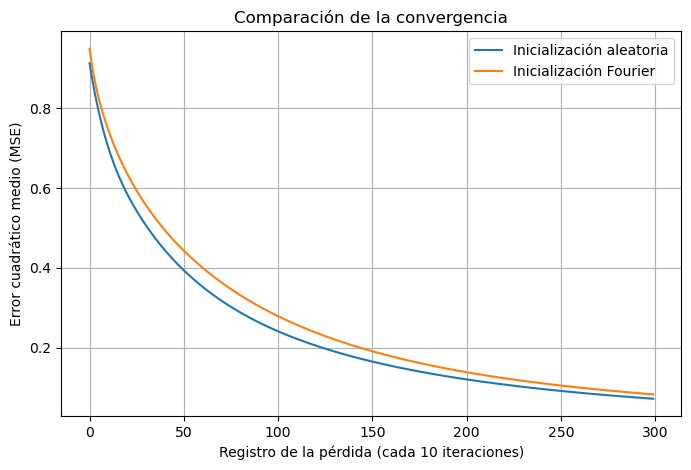

In [13]:
# Crear una figura para comparar ambas curvas de entrenamiento
plt.figure(figsize=(8,5))

# Pérdida de la red inicializada aleatoriamente
plt.plot(h_random, label="Inicialización aleatoria")

# Pérdida de la red inicializada con Fourier
plt.plot(h_fourier, label="Inicialización Fourier")

# Etiquetas de los ejes
plt.xlabel("Registro de la pérdida (cada 10 iteraciones)")
plt.ylabel("Error cuadrático medio (MSE)")

# Título de la gráfica
plt.title("Comparación de la convergencia")

# Mostrar la leyenda
plt.legend()

# Agregar una cuadrícula para facilitar la lectura
plt.grid(True)

plt.show()

# Comparar reconstrucciones

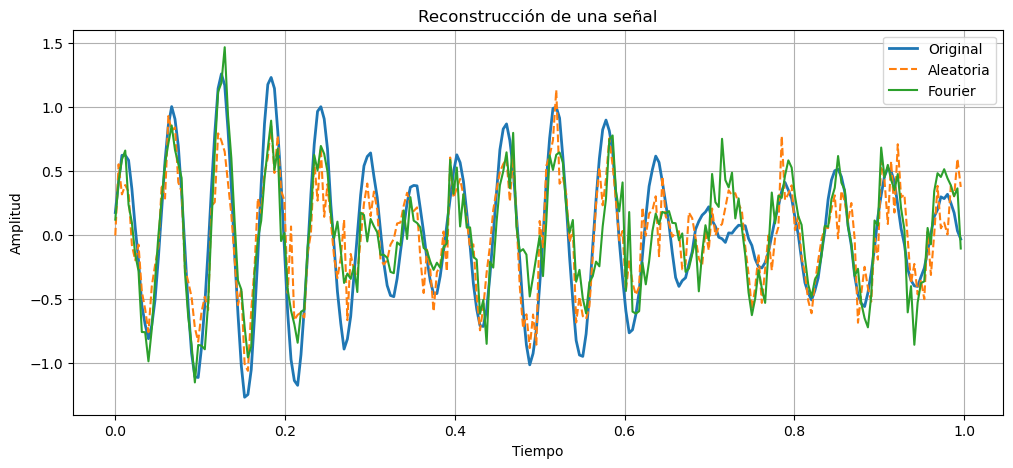

In [14]:
# Seleccionar una señal para evaluar la reconstrucción
x = jnp.array(X[0])

# Reconstrucción usando la red entrenada desde pesos aleatorios
pred_random = forward(params_random, x)

# Reconstrucción usando la red entrenada desde Fourier
pred_fourier = forward(params_fourier, x)

# Crear la figura
plt.figure(figsize=(12,5))

# Señal original
plt.plot(t, x, linewidth=2, label="Original")

# Reconstrucción con inicialización aleatoria
plt.plot(t, pred_random, "--", label="Aleatoria")

# Reconstrucción con inicialización Fourier
plt.plot(t, pred_fourier, label="Fourier")

# Etiquetas y título
plt.xlabel("Tiempo")
plt.ylabel("Amplitud")
plt.title("Reconstrucción de una señal")

plt.legend()
plt.grid(True)

plt.show()

# Análisis del régimen 1

In [15]:
# Extraer únicamente las señales del régimen 1
X1 = X[y == 1]

# Nueva llave para evitar reutilizar exactamente los mismos pesos
key = random.PRNGKey(1)

# Inicializar ambas redes
params_random = init_random(key)
params_fourier = init_fourier(key)

# Entrenar ambas redes únicamente con el régimen 1
_, hist_random = train(params_random, jnp.array(X1))
_, hist_fourier = train(params_fourier, jnp.array(X1))

# Comparar pérdidas del régimen 1

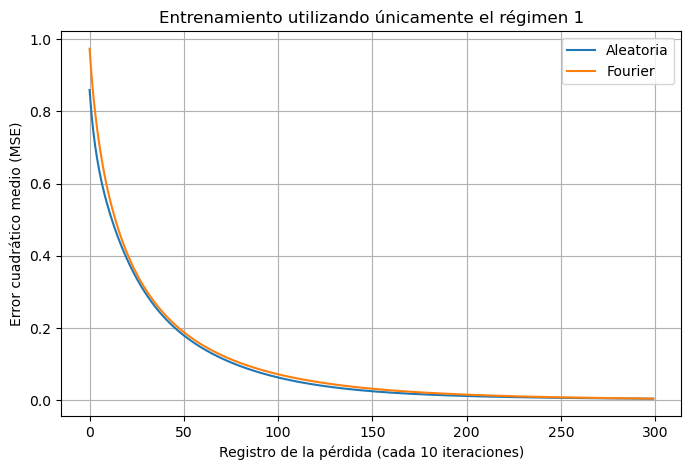

In [16]:
# Crear una nueva figura
plt.figure(figsize=(8,5))

# Curva de pérdida para inicialización aleatoria
plt.plot(hist_random, label="Aleatoria")

# Curva de pérdida para inicialización Fourier
plt.plot(hist_fourier, label="Fourier")

# Título y etiquetas
plt.title("Entrenamiento utilizando únicamente el régimen 1")
plt.xlabel("Registro de la pérdida (cada 10 iteraciones)")
plt.ylabel("Error cuadrático medio (MSE)")

plt.legend()
plt.grid(True)

plt.show()

# Compresión al 90 % de energía

In [17]:
# Calcular los coeficientes de Fourier de una señal
coef = W_fourier @ X[0]

# Energía asociada a cada coeficiente
energia = coef**2

# Normalizar para obtener la fracción de energía
energia = energia / energia.sum()

# Ordenar las energías de mayor a menor
energia_ordenada = np.sort(energia)[::-1]

# Calcular la energía acumulada
energia_acumulada = np.cumsum(energia_ordenada)

# Encontrar el número mínimo de coeficientes necesarios para alcanzar el 90 %
n90 = np.argmax(energia_acumulada >= 0.90) + 1

print(f"Coeficientes necesarios para conservar el 90 % de la energía: {n90}")

Coeficientes necesarios para conservar el 90 % de la energía: 4


# Visualización de la energía acumulada

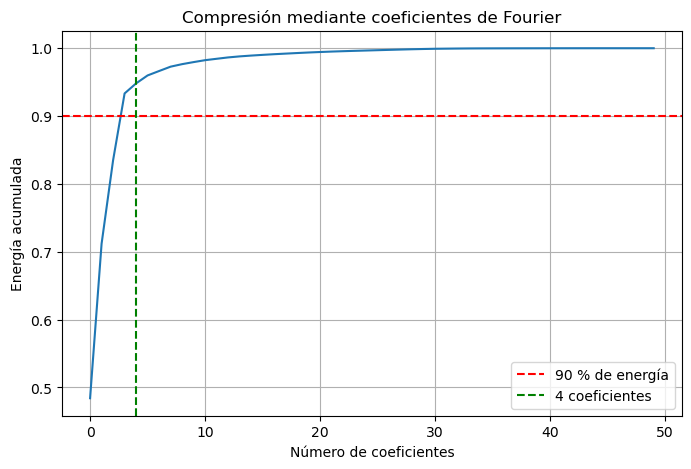

In [18]:
# Crear la figura
plt.figure(figsize=(8,5))

# Graficar la energía acumulada
plt.plot(energia_acumulada)

# Dibujar la línea correspondiente al 90 %
plt.axhline(0.90, color="red", linestyle="--", label="90 % de energía")

# Dibujar el número de coeficientes encontrados
plt.axvline(n90, color="green", linestyle="--", label=f"{n90} coeficientes")

plt.xlabel("Número de coeficientes")
plt.ylabel("Energía acumulada")

plt.title("Compresión mediante coeficientes de Fourier")

plt.legend()
plt.grid(True)

plt.show()